<a href="https://colab.research.google.com/github/aha2003/brain-tumor-classfication-FYP2025/blob/main/Baseline_CNN_MRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install keras-tuner -q
import keras_tuner as kt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import tensorflow as tf
import os

drive.mount('/content/drive')


base_path = '/content/drive/My Drive/Kaggle_Datasets/mri-brain-tumor-dataset'
train_dir = os.path.join(base_path, 'Training')
test_dir = os.path.join(base_path, 'Testing')

Mounted at /content/drive


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16


val_split_pct = 450 / 2935


train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=val_split_pct,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' # For your 4-class multi-class task [cite: 262, 306]
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=val_split_pct,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)


test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 2870 files belonging to 4 classes.
Using 2430 files for training.
Found 2870 files belonging to 4 classes.
Using 440 files for validation.
Found 394 files belonging to 4 classes.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE


normalization_layer = tf.keras.layers.Rescaling(1./255)

def prepare_ds(ds):

  ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
  return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = prepare_ds(train_ds)
val_ds = prepare_ds(val_ds)
test_ds = prepare_ds(test_ds)

print(f"Classes found: {train_ds.class_names if hasattr(train_ds, 'class_names') else '4 types'}")

Classes found: 4 types


In [ ]:
from tensorflow.keras import layers, models

def build_custom_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential([
        # Block 1: 32 filters
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Block 2: 64 filters
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 3: 128 filters
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Classification Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Regularization to prevent overfitting
        layers.Dense(num_classes, activation='softmax')
    ])

    return model


baseline_model = build_custom_cnn()


baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt


def build_tuning_model(hp):

    model_units = hp.Int('dense_units', min_value=64, max_value=256, step=64)
    dropout_rate = hp.Float('dropout_rate', min_value=0.3, max_value=0.7, step=0.1)
    lr = hp.Choice('learning_rate', values=[1e-3, 1e-4, 5e-5])

    model = models.Sequential([
        # Layer 1: 32 filters
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D((2, 2)),

        # Layer 2: 64 filters
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Layer 3: 128 filters
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        # Optimized Dense Layer and Dropout
        layers.Dense(units=model_units, activation='relu'),
        layers.Dropout(rate=dropout_rate),
        layers.Dense(4, activation='softmax') # 4-class multi-class classification
    ])

    # Compile with Adam optimizer
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 2. Re-define the Early Stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 3. Initialize the Tuner
tuner = kt.RandomSearch(
    build_tuning_model,
    objective='val_accuracy',
    max_trials=10,
    directory='tuning_results',
    project_name='brain_tumor_baseline_tuning_v3' # Incremented version to ensure a fresh start
)

# 4. Perform the Search
# We use 10 epochs for tuning to identify the best configuration quickly
tuner.search(train_ds, epochs=10, validation_data=val_ds, callbacks=[early_stop])

# 5. Get and Print the Best Parameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\n--- TUNING RESULTS FOR {base_path} ---")
print(f"Optimal Dense Units: {best_hps.get('dense_units')}")
print(f"Optimal Dropout Rate: {best_hps.get('dropout_rate')}")
print(f"Optimal Learning Rate: {best_hps.get('learning_rate')}")

Trial 10 Complete [00h 48m 14s]
val_accuracy: 0.9022727012634277

Best val_accuracy So Far: 0.9113636612892151
Total elapsed time: 08h 46m 30s

--- TUNING RESULTS FOR /content/drive/My Drive/Kaggle_Datasets/mri-brain-tumor-dataset ---
Optimal Dense Units: 192
Optimal Dropout Rate: 0.4
Optimal Learning Rate: 0.001


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt


final_baseline_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(192, activation='relu'), # Optimal Units: 192
    layers.Dropout(0.4),                   # Optimal Dropout: 0.4
    layers.Dense(4, activation='softmax')
])


final_baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Optimal LR: 0.001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint_path = os.path.join(base_path, 'final_custom_baseline.keras')
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)

print("Starting Final Baseline Training...")
history = final_baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, checkpoint]
)

Starting Final Baseline Training...
Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 400s 3s/step - accuracy: 0.5057 - loss: 1.1547 - val_accuracy: 0.7409 - val_loss: 0.6608
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.7617 - loss: 0.6088 - val_accuracy: 0.7659 - val_loss: 0.5200
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.8272 - loss: 0.4238 - val_accuracy: 0.8477 - val_loss: 0.3719
Epoch 4/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - accuracy: 0.9054 - loss: 0.2461 - val_accuracy: 0.8773 - val_loss: 0.3401
Epoch 5/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.9406 - loss: 0.1609 - val_accuracy: 0.8795 - val_loss: 0.3875
Epoch 6/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.9511 - loss: 0.1439 - val_accuracy: 0.8750 - val_loss: 0.3739
Epoch 7/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.9614 - loss: 0.1030 - val_accuracy: 0.8955 - val_loss: 0.3677
Epoch 8/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accura

In [ ]:

actual_class_names = train_ds.class_names if hasattr(train_ds, 'class_names') else "Dataset was prefetched"
print(f"Alphabetical order of folders: {actual_class_names}")


import os
print(f"Folders in Training: {sorted(os.listdir(train_dir))}")

Alphabetical order of folders: Dataset was prefetched
Folders in Training: ['.DS_Store', 'glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [ ]:
import tensorflow as tf
import os


baseline_path = os.path.join(base_path, 'final_custom_baseline.keras')


model_baseline = tf.keras.models.load_model(baseline_path)

print("✓ Custom Baseline CNN successfully reloaded.")

✓ Custom Baseline CNN successfully reloaded.


Generating predictions for Baseline CNN...


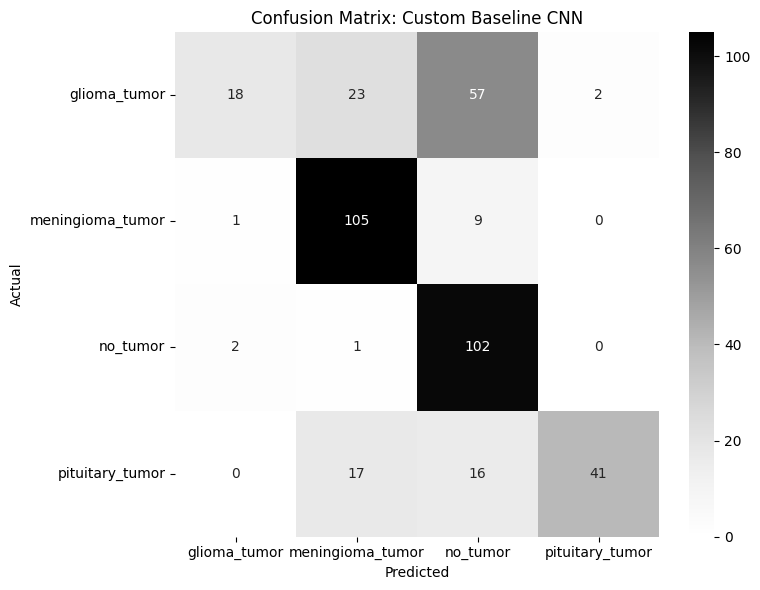

✓ Baseline assets saved to /content/drive/My Drive/Kaggle_Datasets/mri-brain-tumor-dataset


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

def save_baseline_assets(model, test_dataset, save_path):
    print("Generating predictions for Baseline CNN...")
    test_labels, test_preds = [], []


    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        test_labels.extend(np.argmax(labels, axis=1))
        test_preds.extend(np.argmax(preds, axis=1))


    report = classification_report(test_labels, test_preds, target_names=class_names, output_dict=True)
    pd.DataFrame(report).transpose().to_csv(os.path.join(save_path, 'baseline_report.csv'))


    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(test_labels, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix: Custom Baseline CNN')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()

    plt.savefig(os.path.join(save_path, 'baseline_cm.png'), dpi=300)
    plt.show()
    print(f"✓ Baseline assets saved to {save_path}")


save_baseline_assets(model_baseline, test_ds, base_path)

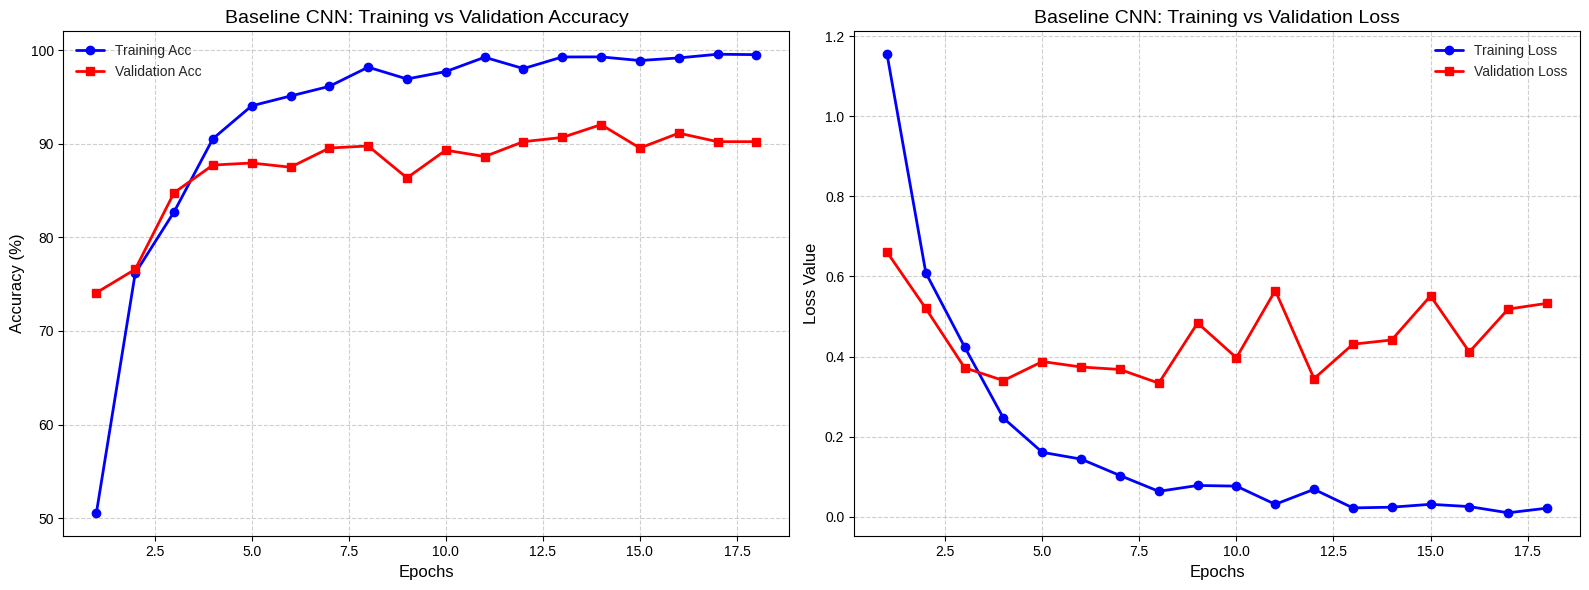

✓ Saved: baseline_learning_curves.png


In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np


epochs = np.arange(1, 19)
train_acc = [0.5057, 0.7617, 0.8272, 0.9054, 0.9406, 0.9511, 0.9614, 0.9819, 0.9693,
             0.9772, 0.9925, 0.9804, 0.9928, 0.9929, 0.9890, 0.9918, 0.9957, 0.9953]
val_acc = [0.7409, 0.7659, 0.8477, 0.8773, 0.8795, 0.8750, 0.8955, 0.8977, 0.8636,
           0.8932, 0.8864, 0.9023, 0.9068, 0.9205, 0.8955, 0.9114, 0.9023, 0.9023]

train_loss = [1.1547, 0.6088, 0.4238, 0.2461, 0.1609, 0.1439, 0.1030, 0.0635, 0.0781,
              0.0765, 0.0311, 0.0685, 0.0221, 0.0239, 0.0311, 0.0254, 0.0099, 0.0215]
val_loss = [0.6608, 0.5200, 0.3719, 0.3401, 0.3875, 0.3739, 0.3677, 0.3336, 0.4838,
            0.3971, 0.5648, 0.3449, 0.4308, 0.4414, 0.5514, 0.4115, 0.5185, 0.5329]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.style.use('seaborn-v0_8-whitegrid')


ax1.plot(epochs, [x * 100 for x in train_acc], 'b-o', label='Training Acc', linewidth=2)
ax1.plot(epochs, [x * 100 for x in val_acc], 'r-s', label='Validation Acc', linewidth=2)
ax1.set_title('Baseline CNN: Training vs Validation Accuracy', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)


ax2.plot(epochs, train_loss, 'b-o', label='Training Loss', linewidth=2)
ax2.plot(epochs, val_loss, 'r-s', label='Validation Loss', linewidth=2)
ax2.set_title('Baseline CNN: Training vs Validation Loss', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss Value', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'baseline_learning_curves.png'), dpi=300)
plt.show()

print("✓ Saved: baseline_learning_curves.png")